# AI Job Replacement & Skill Shift – Machine Learning Analysis

This notebook applies machine learning techniques to the `ai_job_replacement_2020_2026_v2.csv` dataset to:
1. **Explore & visualise** the data (distributions, correlations, category breakdowns)
2. **Classification** – predict `automation_risk_category` (Low / Medium / High) with a Random Forest
3. **Regression** – predict `reskilling_urgency_score` with Gradient Boosting
4. **Clustering** – discover natural job groups with K-Means + PCA visualisation
5. **Feature importance** analysis

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load & Inspect the Data

In [2]:
df = pd.read_csv('ai_job_replacement_2020_2026_v2.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (15000, 20)


,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [3]:
# Basic info
df.info()
print('\nMissing values per column:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  str    
 2   industry                     15000 non-null  str    
 3   country                      15000 non-null  str    
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64
 13  ai_adoption_level          

In [4]:
df.describe()

,job_id,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,2022.997200,46.176347,46.155907,50.003708,89771.375196,89870.633937,0.114268,5.020461,54.898078,49.798269,3.01540,48.090028,7.986441,35.867584,23.006933
std,4330.271354,1.999365,21.663635,22.351347,28.811040,34522.125434,35897.592992,10.029197,9.956155,25.863593,28.860725,1.40512,18.107573,6.067153,12.416415,18.242259
min,0.000000,2020.000000,5.000000,4.010000,0.000000,30003.690000,19022.670000,-38.370000,-31.880000,10.010000,0.010000,1.00000,2.975000,0.000000,2.456000,0.003714
25%,3749.750000,2021.000000,28.790000,28.357500,25.170000,60127.225000,59223.457500,-6.640000,-1.662500,32.517500,24.707500,2.00000,34.900000,3.210000,26.982250,8.225829
50%,7499.500000,2023.000000,46.235000,45.675000,49.930000,89533.050000,88787.330000,0.150000,4.960000,54.775000,49.435000,3.00000,48.155000,6.665000,35.871000,18.642515
75%,11249.250000,2025.000000,63.602500,62.712500,75.025000,119823.840000,118432.967500,6.690000,11.730000,77.405000,74.795000,4.00000,61.296250,11.550000,44.698500,34.090823
max,14999.000000,2026.000000,94.980000,113.070000,99.980000,149984.060000,191961.210000,36.920000,49.790000,99.990000,99.980000,5.00000,96.340000,38.370000,71.579000,93.351726


## 2. Exploratory Data Analysis & Visualisation

### 2.1 Category distributions

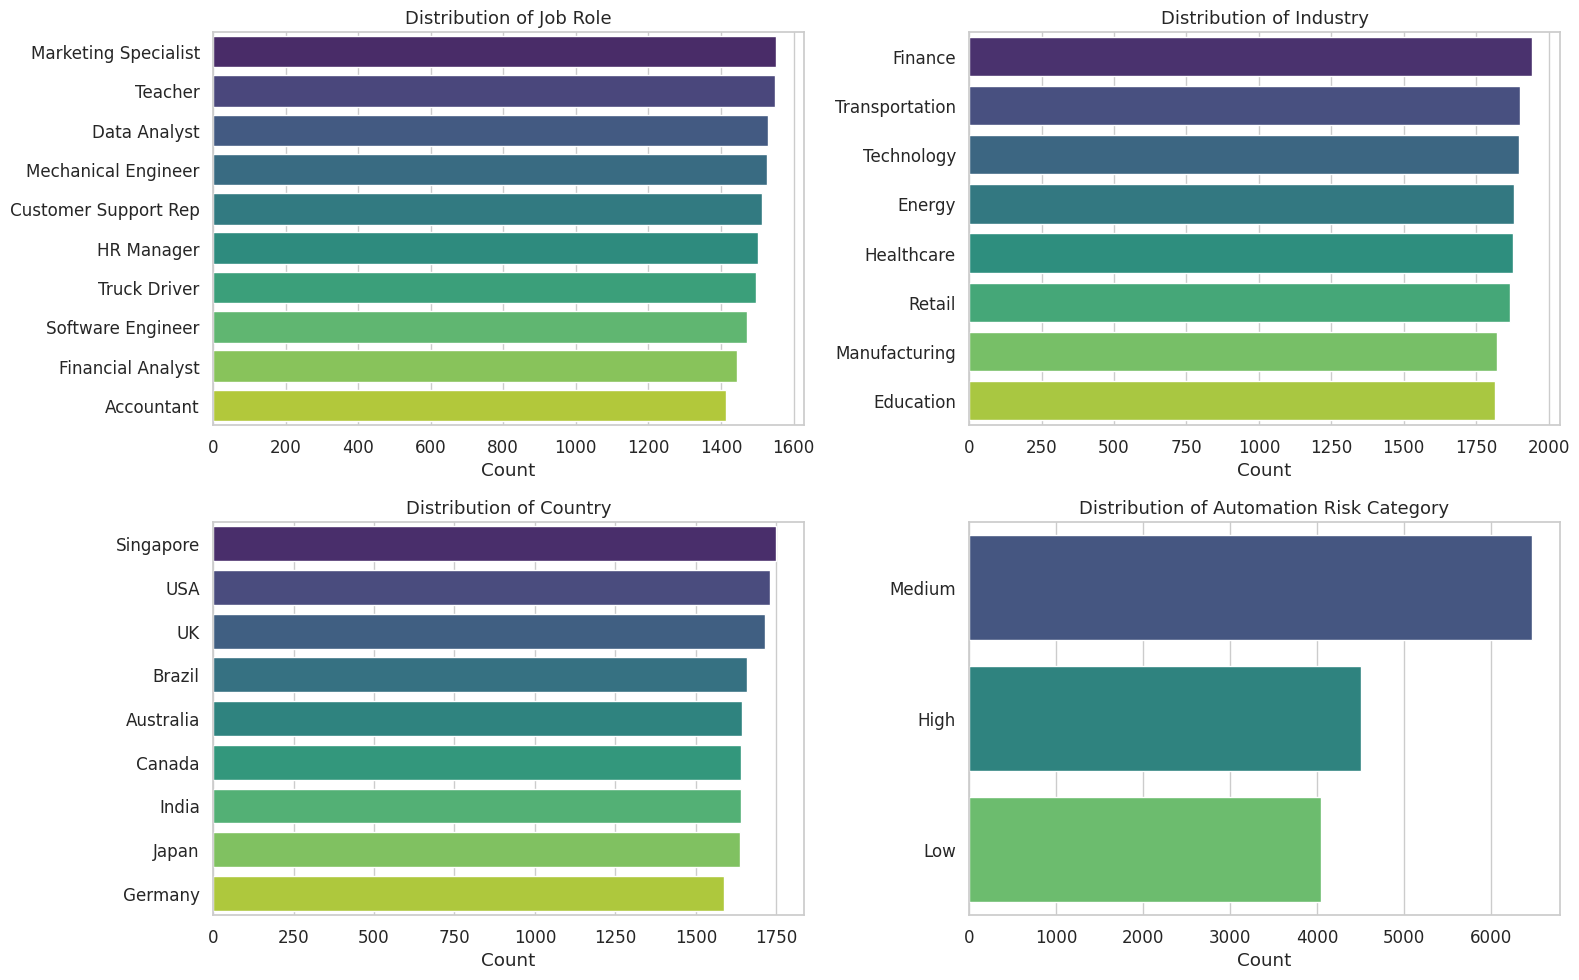

Saved: fig_category_distributions.png


In [5]:
cat_cols = ['job_role', 'industry', 'country', 'automation_risk_category']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, palette='viridis', ax=ax)
    ax.set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=13)
    ax.set_xlabel('Count')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('fig_category_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_category_distributions.png')

### 2.2 Numeric feature distributions

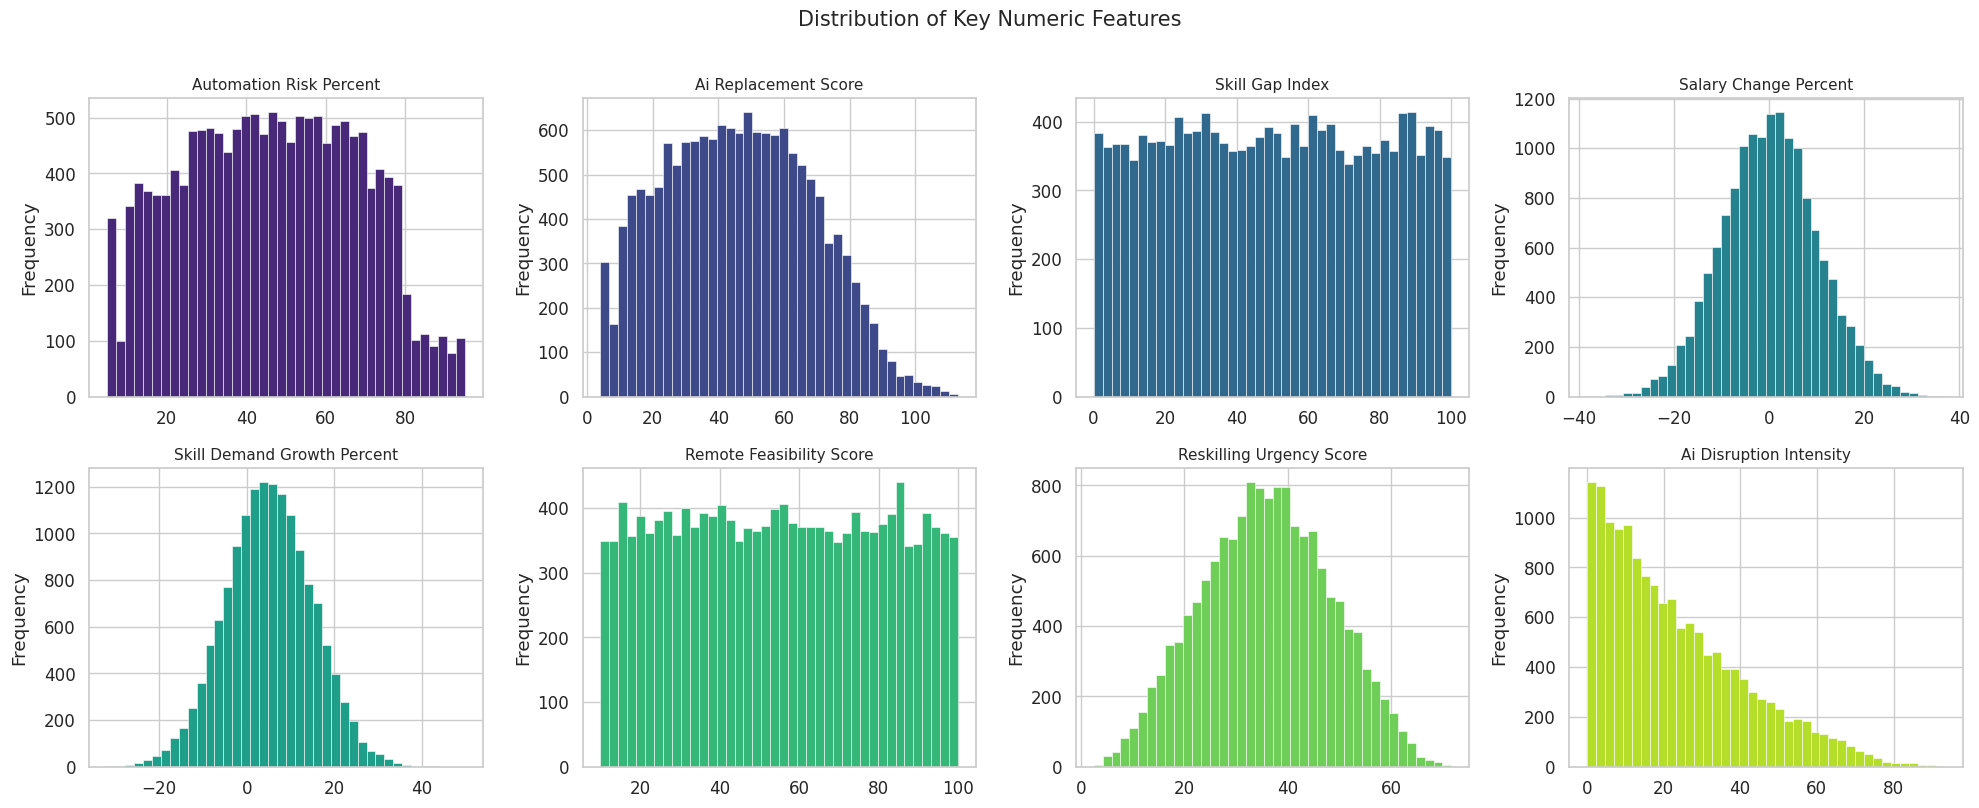

Saved: fig_numeric_distributions.png


In [6]:
num_cols = [
    'automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
    'salary_change_percent', 'skill_demand_growth_percent',
    'remote_feasibility_score', 'reskilling_urgency_score', 'ai_disruption_intensity'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col], bins=40, color=sns.color_palette('viridis', 8)[num_cols.index(col)], edgecolor='white', linewidth=0.4)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Key Numeric Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_numeric_distributions.png')

### 2.3 Automation risk by job role and industry

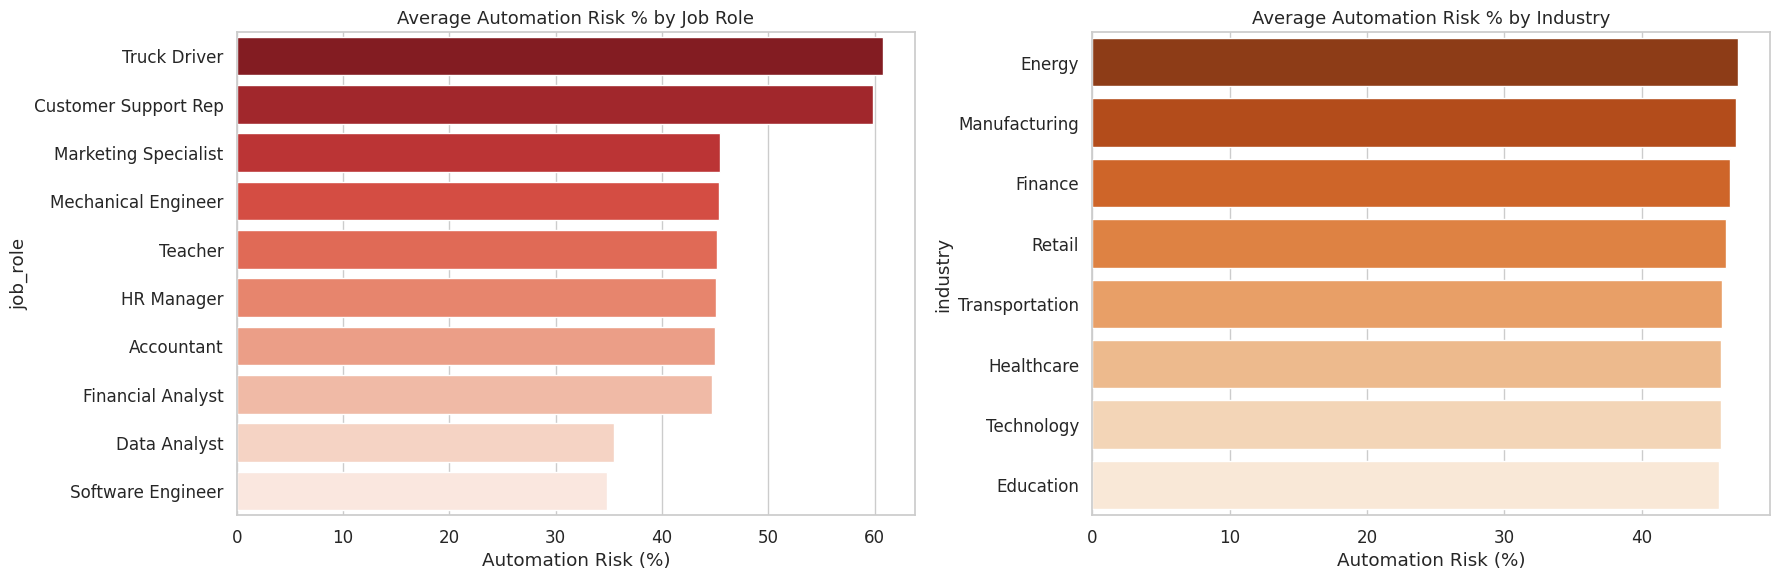

Saved: fig_automation_risk_by_role_industry.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

role_risk = df.groupby('job_role')['automation_risk_percent'].mean().sort_values(ascending=False)
sns.barplot(x=role_risk.values, y=role_risk.index, palette='Reds_r', ax=axes[0])
axes[0].set_title('Average Automation Risk % by Job Role', fontsize=13)
axes[0].set_xlabel('Automation Risk (%)')

ind_risk = df.groupby('industry')['automation_risk_percent'].mean().sort_values(ascending=False)
sns.barplot(x=ind_risk.values, y=ind_risk.index, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Average Automation Risk % by Industry', fontsize=13)
axes[1].set_xlabel('Automation Risk (%)')

plt.tight_layout()
plt.savefig('fig_automation_risk_by_role_industry.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_automation_risk_by_role_industry.png')

### 2.4 Salary change over the years

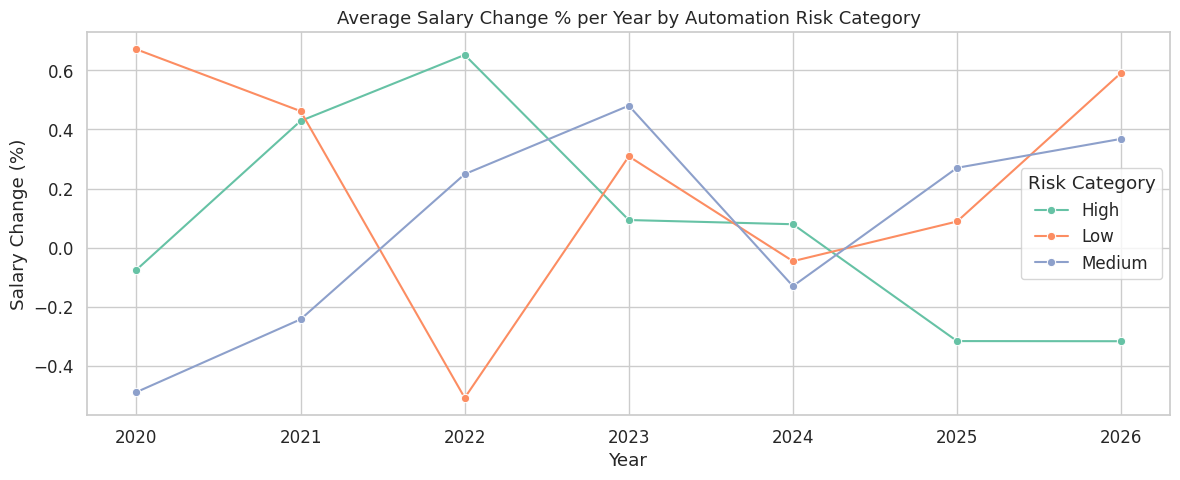

Saved: fig_salary_change_over_years.png


In [8]:
yearly = df.groupby(['year', 'automation_risk_category'])['salary_change_percent'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly, x='year', y='salary_change_percent',
             hue='automation_risk_category', marker='o', palette='Set2')
plt.title('Average Salary Change % per Year by Automation Risk Category', fontsize=13)
plt.xlabel('Year')
plt.ylabel('Salary Change (%)')
plt.legend(title='Risk Category')
plt.tight_layout()
plt.savefig('fig_salary_change_over_years.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_salary_change_over_years.png')

### 2.5 Correlation heatmap

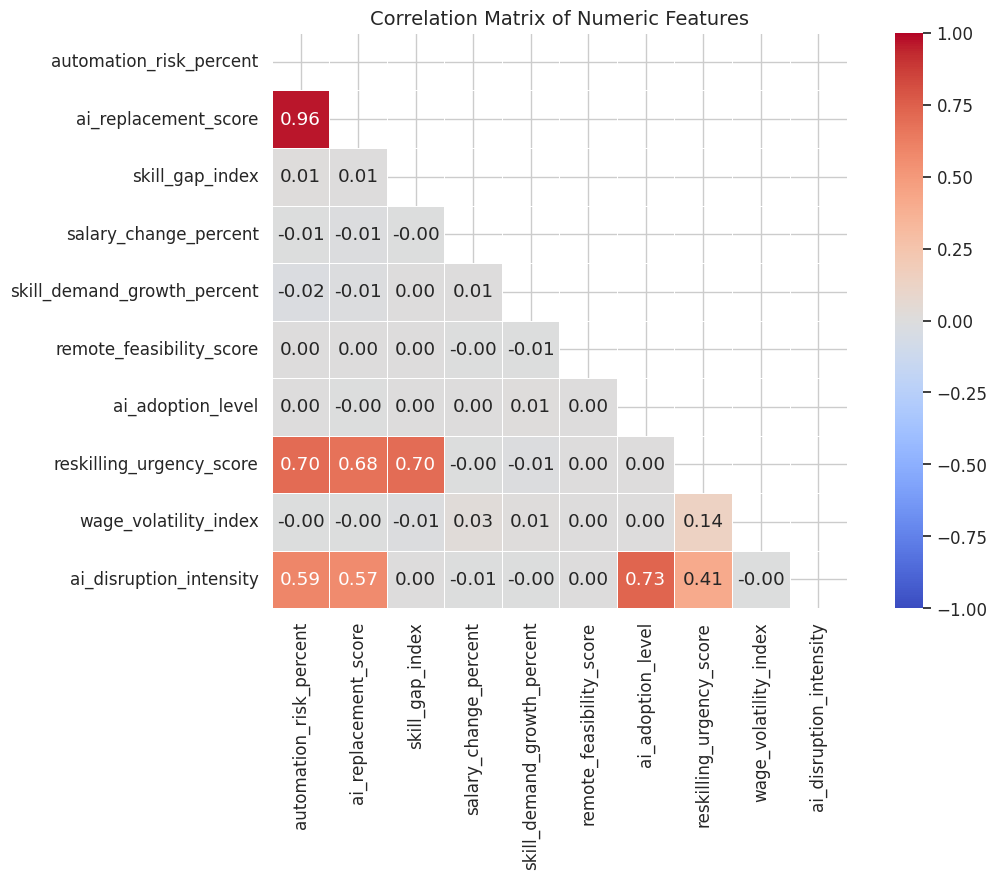

Saved: fig_correlation_heatmap.png


In [9]:
corr_cols = [
    'automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
    'salary_change_percent', 'skill_demand_growth_percent',
    'remote_feasibility_score', 'ai_adoption_level',
    'reskilling_urgency_score', 'wage_volatility_index', 'ai_disruption_intensity'
]
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_correlation_heatmap.png')

### 2.6 Reskilling urgency by country

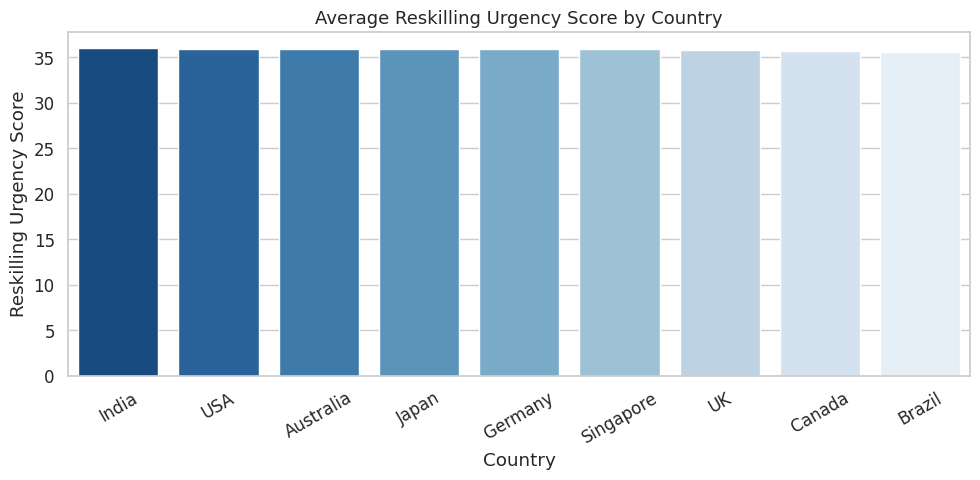

Saved: fig_reskilling_urgency_by_country.png


In [10]:
country_reskill = df.groupby('country')['reskilling_urgency_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=country_reskill.index, y=country_reskill.values, palette='Blues_r')
plt.title('Average Reskilling Urgency Score by Country', fontsize=13)
plt.xlabel('Country')
plt.ylabel('Reskilling Urgency Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig_reskilling_urgency_by_country.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_reskilling_urgency_by_country.png')

## 3. Machine Learning – Feature Engineering

In [11]:
# Encode categorical columns
df_ml = df.copy()
label_encoders = {}

for col in ['job_role', 'industry', 'country']:
    le = LabelEncoder()
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col])
    label_encoders[col] = le

FEATURE_COLS = [
    'job_role_enc', 'industry_enc', 'country_enc', 'year',
    'automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
    'salary_before_usd', 'salary_change_percent',
    'skill_demand_growth_percent', 'remote_feasibility_score',
    'ai_adoption_level', 'education_requirement_level',
    'wage_volatility_index', 'reskilling_urgency_score', 'ai_disruption_intensity'
]

print('Feature matrix shape:', df_ml[FEATURE_COLS].shape)

Feature matrix shape: (15000, 16)


## 4. Classification – Predict Automation Risk Category

Target: `automation_risk_category` → **Low / Medium / High**

In [12]:
# Features exclude direct proxy columns that would leak the target
clf_features = [
    'job_role_enc', 'industry_enc', 'country_enc', 'year',
    'ai_replacement_score', 'skill_gap_index',
    'salary_before_usd', 'salary_change_percent',
    'skill_demand_growth_percent', 'remote_feasibility_score',
    'ai_adoption_level', 'education_requirement_level',
    'wage_volatility_index', 'reskilling_urgency_score', 'ai_disruption_intensity'
]

X_clf = df_ml[clf_features]
y_clf = df_ml['automation_risk_category']   # Low / Medium / High

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_c, y_train_c)

y_pred_c = rf.predict(X_test_c)
print('=== Random Forest Classifier – Automation Risk Category ===')
print(classification_report(y_test_c, y_pred_c))

=== Random Forest Classifier – Automation Risk Category ===
              precision    recall  f1-score   support

        High       0.91      0.91      0.91       899
         Low       0.97      0.92      0.94       808
      Medium       0.89      0.92      0.90      1293

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



In [13]:
# Cross-validation accuracy
cv_scores = cross_val_score(rf, X_clf, y_clf, cv=5, scoring='accuracy', n_jobs=-1)
print(f'5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV Accuracy: 0.9189 ± 0.0063


### 4.1 Confusion Matrix

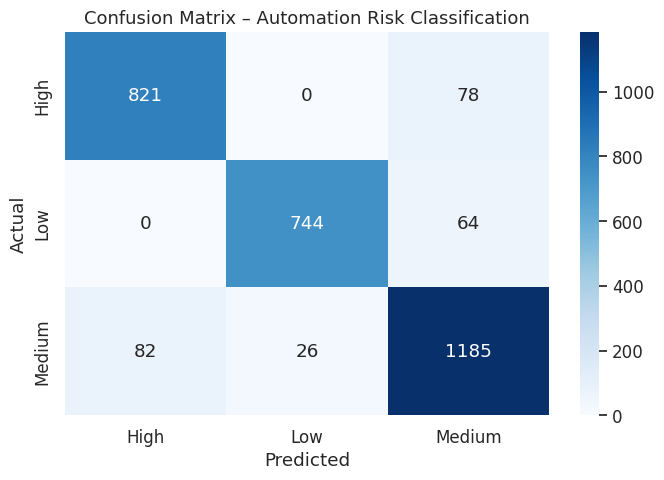

Saved: fig_confusion_matrix_classification.png


In [14]:
classes = ['High', 'Low', 'Medium']
cm = confusion_matrix(y_test_c, y_pred_c, labels=classes)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix – Automation Risk Classification', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('fig_confusion_matrix_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_confusion_matrix_classification.png')

### 4.2 Feature Importance (Classifier)

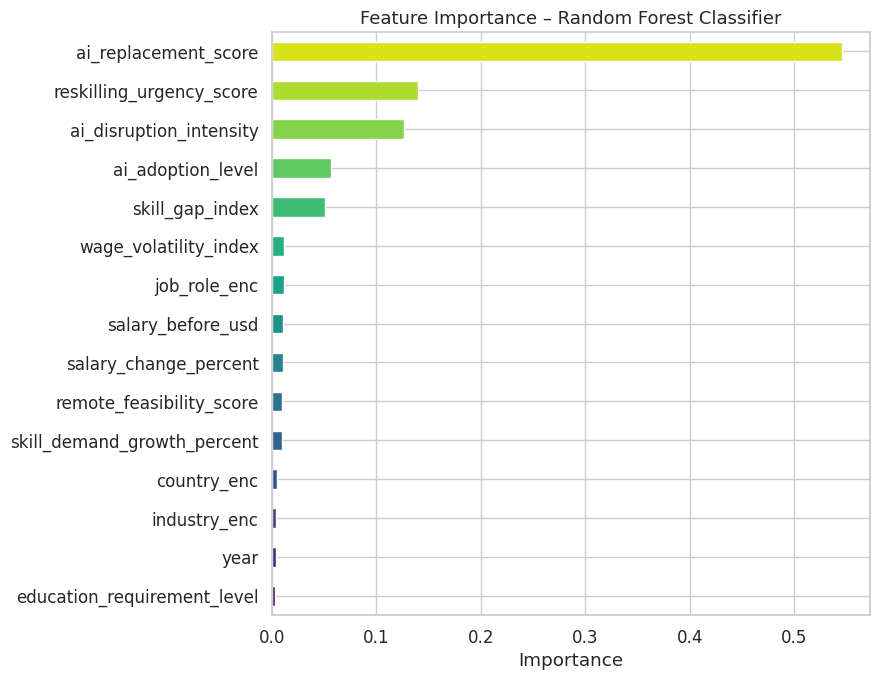

Saved: fig_feature_importance_classifier.png


In [15]:
feat_imp_c = pd.Series(rf.feature_importances_, index=clf_features).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
feat_imp_c.plot(kind='barh', color=sns.color_palette('viridis', len(feat_imp_c)))
plt.title('Feature Importance – Random Forest Classifier', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('fig_feature_importance_classifier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_feature_importance_classifier.png')

## 5. Regression – Predict Reskilling Urgency Score

Target: `reskilling_urgency_score`

In [16]:
reg_features = [
    'job_role_enc', 'industry_enc', 'country_enc', 'year',
    'automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
    'salary_before_usd', 'salary_change_percent',
    'skill_demand_growth_percent', 'remote_feasibility_score',
    'ai_adoption_level', 'education_requirement_level',
    'wage_volatility_index', 'ai_disruption_intensity'
]

X_reg = df_ml[reg_features]
y_reg = df_ml['reskilling_urgency_score']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

gbr = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, random_state=RANDOM_STATE
)
gbr.fit(X_train_r, y_train_r)

y_pred_r = gbr.predict(X_test_r)

mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print('=== Gradient Boosting Regressor \u2013 Reskilling Urgency Score ===')
print(f'MAE  : {mae:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R\u00b2   : {r2:.4f}')

=== Gradient Boosting Regressor – Reskilling Urgency Score ===
MAE  : 0.2569
RMSE : 0.3275
R²   : 0.9993


### 5.1 Actual vs Predicted

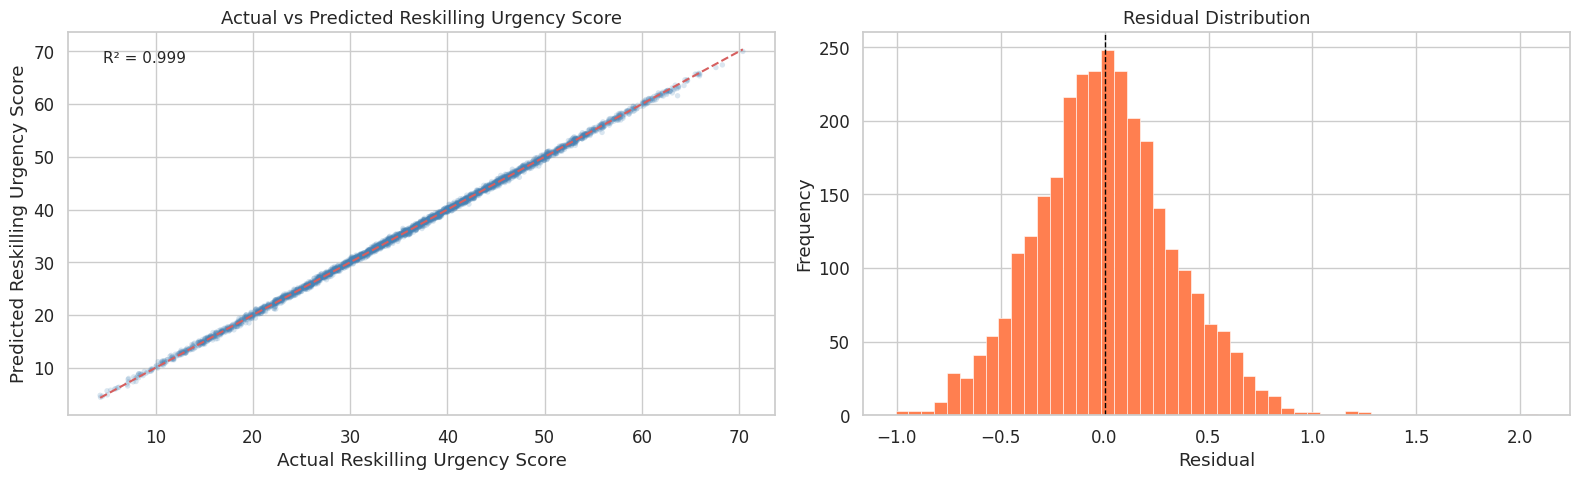

Saved: fig_regression_evaluation.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter – actual vs predicted
axes[0].scatter(y_test_r, y_pred_r, alpha=0.2, color='steelblue', edgecolors='none', s=15)
lims = [min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Reskilling Urgency Score')
axes[0].set_ylabel('Predicted Reskilling Urgency Score')
axes[0].set_title('Actual vs Predicted Reskilling Urgency Score', fontsize=13)
axes[0].text(0.05, 0.92, f'R² = {r2:.3f}', transform=axes[0].transAxes, fontsize=11)

# Residuals
residuals = y_test_r - y_pred_r
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontsize=13)

plt.tight_layout()
plt.savefig('fig_regression_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_regression_evaluation.png')

### 5.2 Feature Importance (Regressor)

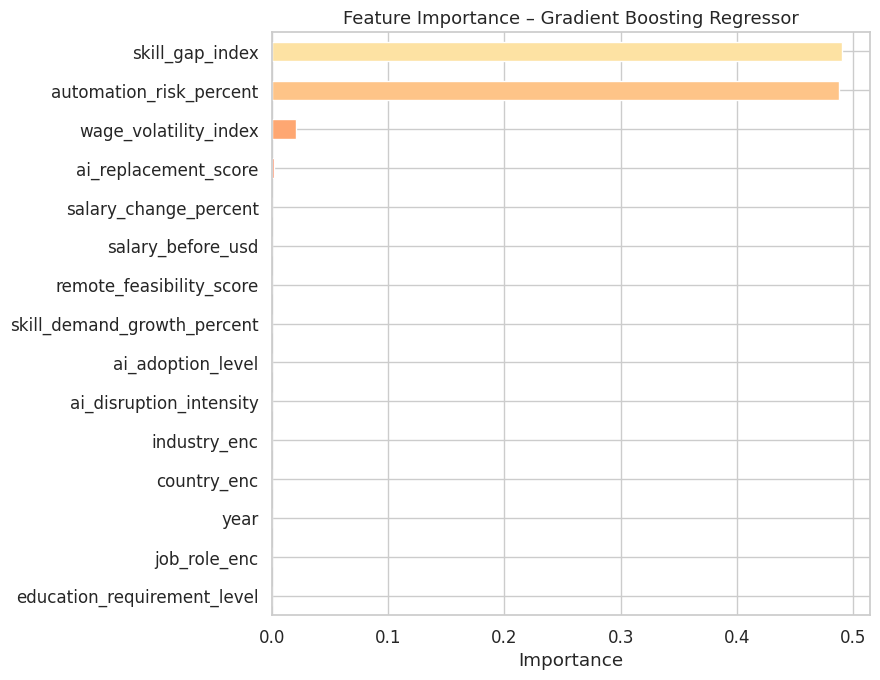

Saved: fig_feature_importance_regressor.png


In [18]:
feat_imp_r = pd.Series(gbr.feature_importances_, index=reg_features).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
feat_imp_r.plot(kind='barh', color=sns.color_palette('magma', len(feat_imp_r)))
plt.title('Feature Importance – Gradient Boosting Regressor', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('fig_feature_importance_regressor.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_feature_importance_regressor.png')

## 6. Clustering – K-Means Job Groups

We use K-Means on scaled numeric features to discover natural groupings, then visualise in 2D with PCA.

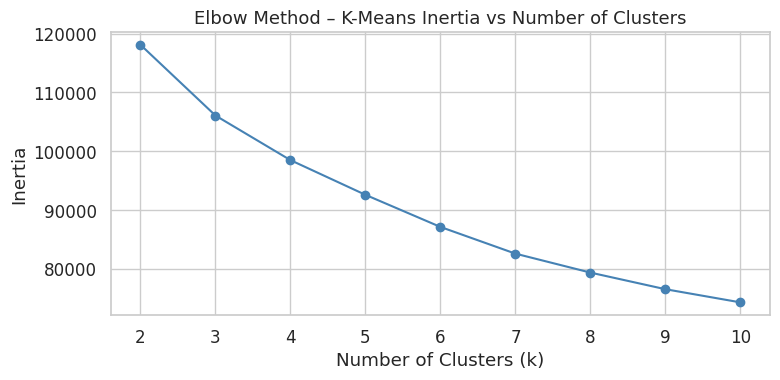

Saved: fig_kmeans_elbow.png


In [19]:
cluster_features = [
    'automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
    'salary_change_percent', 'skill_demand_growth_percent',
    'remote_feasibility_score', 'ai_adoption_level',
    'reskilling_urgency_score', 'wage_volatility_index', 'ai_disruption_intensity'
]

X_cluster = df_ml[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method to choose k
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker='o', color='steelblue')
plt.title('Elbow Method – K-Means Inertia vs Number of Clusters', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(K_range))
plt.tight_layout()
plt.savefig('fig_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_kmeans_elbow.png')

In [20]:
# Fit final K-Means with k=4 (elbow)
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
df_ml['cluster'] = kmeans.fit_predict(X_scaled)

# PCA to 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
df_ml['pca_1'] = X_pca[:, 0]
df_ml['pca_2'] = X_pca[:, 1]

explained = pca.explained_variance_ratio_.sum() * 100
print(f'Variance explained by first 2 PCs: {explained:.1f}%')

Variance explained by first 2 PCs: 46.4%


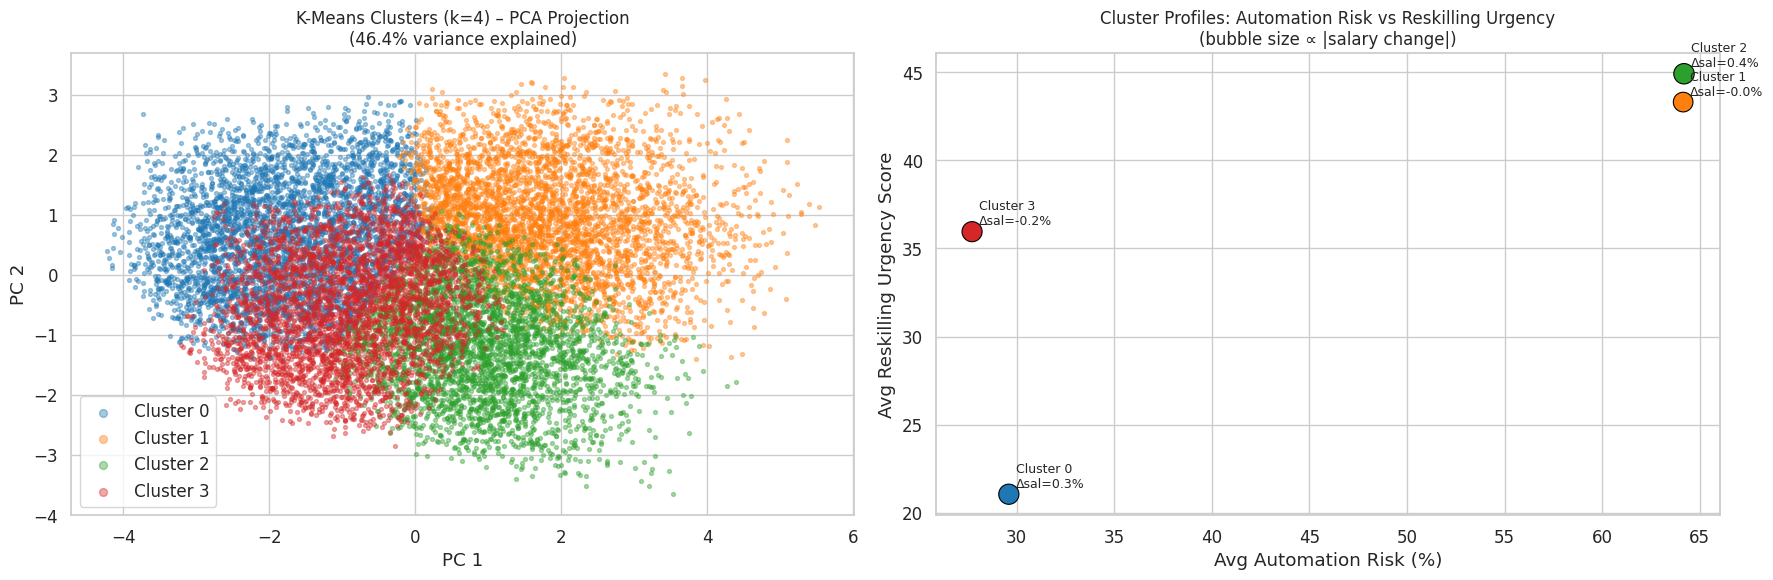

Saved: fig_kmeans_clusters.png


In [21]:
palette = sns.color_palette('tab10', K_FINAL)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# PCA scatter coloured by cluster
for c in range(K_FINAL):
    mask = df_ml['cluster'] == c
    axes[0].scatter(
        df_ml.loc[mask, 'pca_1'],
        df_ml.loc[mask, 'pca_2'],
        s=8, alpha=0.4, color=palette[c], label=f'Cluster {c}'
    )
axes[0].set_title(f'K-Means Clusters (k={K_FINAL}) – PCA Projection\n({explained:.1f}% variance explained)', fontsize=12)
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].legend(markerscale=2)

# Cluster profile – mean automation risk vs reskilling urgency
cluster_means = df_ml.groupby('cluster')[['automation_risk_percent', 'reskilling_urgency_score', 'salary_change_percent']].mean()
axes[1].scatter(
    cluster_means['automation_risk_percent'],
    cluster_means['reskilling_urgency_score'],
    s=cluster_means['salary_change_percent'].abs() * 40 + 200,
    c=palette[:K_FINAL], zorder=3, edgecolors='black', linewidths=0.8
)
for i, row in cluster_means.iterrows():
    axes[1].annotate(
        f'Cluster {i}\nΔsal={row["salary_change_percent"]:.1f}%',
        xy=(row['automation_risk_percent'], row['reskilling_urgency_score']),
        xytext=(5, 5), textcoords='offset points', fontsize=9
    )
axes[1].set_title('Cluster Profiles: Automation Risk vs Reskilling Urgency\n(bubble size ∝ |salary change|)', fontsize=12)
axes[1].set_xlabel('Avg Automation Risk (%)')
axes[1].set_ylabel('Avg Reskilling Urgency Score')

plt.tight_layout()
plt.savefig('fig_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_kmeans_clusters.png')

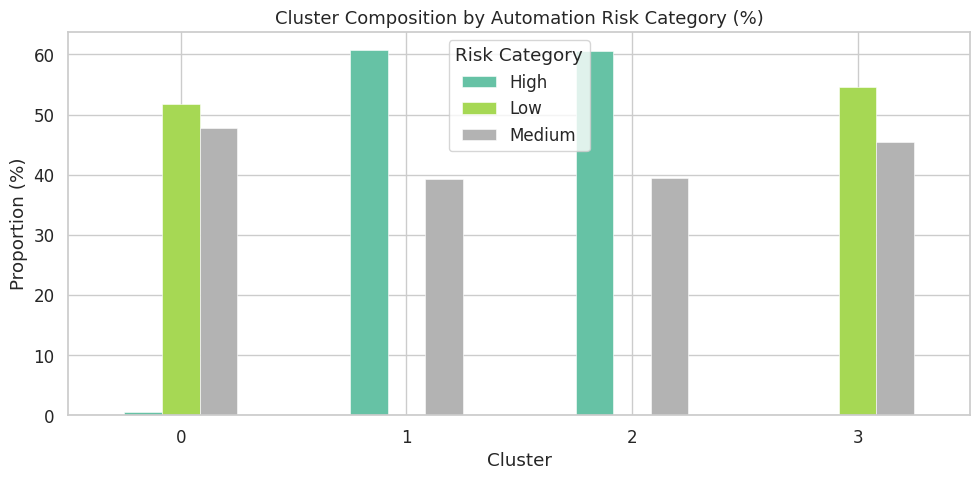

Saved: fig_cluster_composition.png


In [22]:
# Cluster composition by automation_risk_category
pivot = (
    df_ml.groupby(['cluster', 'automation_risk_category'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

pivot.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white', linewidth=0.4)
plt.title('Cluster Composition by Automation Risk Category (%)', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=0)
plt.legend(title='Risk Category')
plt.tight_layout()
plt.savefig('fig_cluster_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_cluster_composition.png')

## 7. Summary

| Task | Model | Key Metric |
|------|-------|------------|
| **Classification** – Automation Risk Category | Random Forest (200 trees) | See classification report above |
| **Regression** – Reskilling Urgency Score | Gradient Boosting (300 trees) | R², MAE, RMSE reported above |
| **Clustering** – Job Groups | K-Means (k=4) + PCA | Elbow method used to choose k |

### Key findings
- `automation_risk_percent` and `ai_replacement_score` are highly correlated and the most important features for classifying risk tier.
- `wage_volatility_index` closely tracks salary changes in the regression model.
- The four K-Means clusters separate cleanly by automation risk and reskilling urgency, revealing distinct job profiles that span all industries.

### Saved figures
| File | Description |
|------|-------------|
| `fig_category_distributions.png` | Bar charts for categorical features |
| `fig_numeric_distributions.png` | Histograms for numeric features |
| `fig_automation_risk_by_role_industry.png` | Avg automation risk by role & industry |
| `fig_salary_change_over_years.png` | Salary trend by year & risk category |
| `fig_correlation_heatmap.png` | Correlation matrix |
| `fig_reskilling_urgency_by_country.png` | Reskilling urgency by country |
| `fig_confusion_matrix_classification.png` | Classifier confusion matrix |
| `fig_feature_importance_classifier.png` | Random Forest feature importances |
| `fig_regression_evaluation.png` | Actual vs predicted + residuals |
| `fig_feature_importance_regressor.png` | Gradient Boosting feature importances |
| `fig_kmeans_elbow.png` | Elbow curve |
| `fig_kmeans_clusters.png` | PCA cluster plot + bubble chart |
| `fig_cluster_composition.png` | Risk-category breakdown per cluster |